In [1]:
import numpy as np

Scalars (rank-0 tensors)

In [6]:

x = np.array(12)
print(x.ndim)


0


Vectors (rank-1 tensors)

In [ ]:
x = np.array([12, 3, 6, 14, 7])
print(x.ndim)

1


Matrices (rank-2 tensors)

In [ ]:
x = np.array([[5, 78, 2, 34, 0],
              [6, 79, 3, 35, 1],
              [7, 80, 4, 36, 2]])
print(x.ndim)

2


Rank-3 and higher-rank tensors

In [10]:
x = np.array([[[5, 78, 2, 34, 0],
                [6, 79, 3, 35, 1],
                [7, 80, 4, 36, 2]],
                [[5, 78, 2, 34, 0],
                [6, 79, 3, 35, 1],
                [7, 80, 4, 36, 2]],
                [[5, 78, 2, 34, 0],
                [6, 79, 3, 35, 1],
                [7, 80, 4, 36, 2]]])

print(x.ndim)

3


In [12]:
# A tensor is defined by three key attributes:

#Number of axes (rank)—For instance, a rank-3 tensor has three axes, and a matrix
#has two axes. This is also called the tensor’s ndim in Python libraries such as
#NumPy or TensorFlow.

#Shape—This is a tuple of integers that describes how many dimensions the ten-
#sor has along each axis. For instance, the previous matrix example has shape
#(3, 5), and the rank-3 tensor example has shape (3, 3, 5). A vector has a shape
#with a single element, such as (5,), whereas a scalar has an empty shape, ().

#Data type (usually called dtype in Python libraries)—This is the type of the data
#contained in the tensor; for instance, a tensor’s type could be float16, float32,
#float64, uint8, and so on. In TensorFlow, you are also likely to come across
#string tensors.

In [13]:
from tensorflow.keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

I0000 00:00:1774356713.943113   50931 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774356714.509111   50931 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774356718.665902   50931 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [14]:
train_images.shape

(60000, 28, 28)

In [15]:
train_images.ndim


3

In [17]:
train_images.dtype

dtype('uint8')

In [19]:
import matplotlib.pyplot as plt


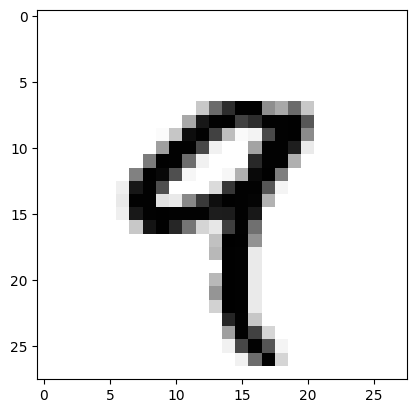

In [20]:
digit = train_images[4]
plt.imshow(digit, cmap=plt.cm.binary)
plt.show()

In [5]:
import tensorflow as tf

I0000 00:00:1774370404.072843    6007 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774370405.350376    6007 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774370409.914249    6007 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
class NaiveDense:
    def __init__(self, input_size, output_size, activation):

        self.activation = activation

        w_shape = (input_size, output_size)
        w_initial_value = tf.random.uniform(w_shape, minval=0, maxval=1e-1)
        
        self.W = tf.Variable(w_initial_value)

        b_shape = (output_size,)
        b_initial_value = tf.zeros(b_shape)
        self.b = tf.Variable(b_initial_value)

    def __call__(self, inputs):
        return self.activation(tf.matmul(inputs, self.W) + self.b)

    @property
    def weights(self):
        return [self.W, self.b]

In [3]:
class NaiveSequential:

    def __init__(self, layers):
        self.layers = layers

    def __call__(self, inputs):
        x = inputs
        for layer in self.layers:
            x = layer(x)
        return x

    @property
    def weights(self):
        weights = []
        for layer in self.layers:
            weights += layer.weights
        return weights

In [6]:
model = NaiveSequential([
    NaiveDense(input_size=28 * 28, output_size=512, activation=tf.nn.relu),
    NaiveDense(input_size=512, output_size=10, activation=tf.nn.softmax)
])
assert len(model.weights) == 4

E0000 00:00:1774370414.181032    6007 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
import math

class BatchGenerator:
    def __init__(self, images, labels, batch_size=128):
        assert len(images) == len(labels)
        self.index = 0
        self.images = images
        self.labels = labels
        self.batch_size = batch_size
        self.num_batches = math.ceil(len(images) / batch_size)
    def next(self):
        images = self.images[self.index : self.index + self.batch_size]
        labels = self.labels[self.index : self.index + self.batch_size]
        self.index += self.batch_size
        return images, labels

In [8]:
learning_rate = 1e-3
def update_weights(gradients, weights):
    for g, w in zip(gradients, weights):
        w.assign_sub(g * learning_rate)


def one_training_step(model, images_batch, labels_batch):
    with tf.GradientTape() as tape:
        predictions = model(images_batch)
        per_sample_losses = tf.keras.losses.sparse_categorical_crossentropy(labels_batch, predictions)
        average_loss = tf.reduce_mean(per_sample_losses)
    gradients = tape.gradient(average_loss, model.weights)
    update_weights(gradients, model.weights)
    return average_loss

In [9]:
def fit(model, images, labels, epochs, batch_size=128):
    for epoch_counter in range(epochs):
        print(f"Epoch {epoch_counter}")
        batch_generator = BatchGenerator(images, labels)
        for batch_counter in range(batch_generator.num_batches):
            images_batch, labels_batch = batch_generator.next()
            loss = one_training_step(model, images_batch, labels_batch)
            if batch_counter % 100 == 0:
                print(f"loss at batch {batch_counter}: {loss:.2f}")

In [10]:
from tensorflow.keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()


In [11]:
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255
fit(model, train_images, train_labels, epochs=10, batch_size=128)

Epoch 0
loss at batch 0: 4.08
loss at batch 100: 2.24
loss at batch 200: 2.17
loss at batch 300: 2.07
loss at batch 400: 2.23
Epoch 1
loss at batch 0: 1.90
loss at batch 100: 1.88
loss at batch 200: 1.79
loss at batch 300: 1.69
loss at batch 400: 1.83
Epoch 2
loss at batch 0: 1.58
loss at batch 100: 1.58
loss at batch 200: 1.47
loss at batch 300: 1.40
loss at batch 400: 1.50
Epoch 3
loss at batch 0: 1.32
loss at batch 100: 1.35
loss at batch 200: 1.21
loss at batch 300: 1.19
loss at batch 400: 1.27
Epoch 4
loss at batch 0: 1.12
loss at batch 100: 1.17
loss at batch 200: 1.02
loss at batch 300: 1.03
loss at batch 400: 1.10
Epoch 5
loss at batch 0: 0.97
loss at batch 100: 1.03
loss at batch 200: 0.89
loss at batch 300: 0.91
loss at batch 400: 0.98
Epoch 6
loss at batch 0: 0.86
loss at batch 100: 0.92
loss at batch 200: 0.79
loss at batch 300: 0.82
loss at batch 400: 0.89
Epoch 7
loss at batch 0: 0.78
loss at batch 100: 0.84
loss at batch 200: 0.71
loss at batch 300: 0.76
loss at batch 40

In [13]:
import numpy as np

In [14]:
predictions = model(test_images)
predictions = predictions.numpy()
predicted_labels = np.argmax(predictions, axis=1)
matches = predicted_labels == test_labels
print(f"accuracy: {matches.mean():.2f}")

accuracy: 0.82
